# echoes — vibe NLP layer
### `05_vibe_nlp.ipynb`

**The creative differentiator.**

Every other recommendation system uses listening history.
This layer lets the user *describe a feeling* and shifts
the recommendations to match.

"3am rain, windows down, a little broken"
→ parsed into audio feature weights
→ biases the hybrid ranker toward slower, melancholic, atmospheric artists

**Pipeline:**
1. User types a free-text vibe description
2. `sentence-transformers` embeds it into a 384-dim vector
3. A learned projection maps that vector to audio feature weights
4. Weights shift the hybrid ranking — mood-matched playlist

**Model:** `all-MiniLM-L6-v2` — free, runs on CPU, 80MB

---

In [1]:
import os
import json
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv('/Users/saturnine/echoes/.env', override=True)

print("✓ Environment ready")
print("✓ Key loaded:", os.getenv("LASTFM_API_KEY")[:6] + "...")

✓ Environment ready
✓ Key loaded: 24381e...


## 1. install & load sentence-transformers

`all-MiniLM-L6-v2` is a lightweight but powerful sentence embedding model.
It maps any text to a 384-dimensional vector where semantically similar
sentences are close together in vector space.

"sad late night drive" and "melancholic 3am" will have very similar vectors.
That's what makes this work.

In [2]:
from sentence_transformers import SentenceTransformer

print("Loading sentence-transformers model...")
print("(downloads ~80MB on first run, cached after)")

model = SentenceTransformer('all-MiniLM-L6-v2')

print("✓ Model loaded")
print(f"✓ Embedding dimension: {model.get_sentence_embedding_dimension()}")

# quick sanity check
test_sentences = [
    "sad late night drive",
    "melancholic 3am rain",
    "happy summer beach party",
    "aggressive workout hype",
    "peaceful morning coffee",
]

embeddings = model.encode(test_sentences)
sim_matrix = np.inner(embeddings, embeddings)

print("\nSemantic similarity test:")
print("(1.0 = identical, 0.0 = unrelated)\n")
for i, s1 in enumerate(test_sentences):
    for j, s2 in enumerate(test_sentences):
        if j > i:
            print(f"  {sim_matrix[i,j]:.3f}  '{s1}' ↔ '{s2}'")

/opt/anaconda3/envs/echoes/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading sentence-transformers model...
(downloads ~80MB on first run, cached after)


Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 9115.74it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded
✓ Embedding dimension: 384

Semantic similarity test:
(1.0 = identical, 0.0 = unrelated)

  0.320  'sad late night drive' ↔ 'melancholic 3am rain'
  0.189  'sad late night drive' ↔ 'happy summer beach party'
  0.070  'sad late night drive' ↔ 'aggressive workout hype'
  0.206  'sad late night drive' ↔ 'peaceful morning coffee'
  0.234  'melancholic 3am rain' ↔ 'happy summer beach party'
  0.122  'melancholic 3am rain' ↔ 'aggressive workout hype'
  0.301  'melancholic 3am rain' ↔ 'peaceful morning coffee'
  0.170  'happy summer beach party' ↔ 'aggressive workout hype'
  0.191  'happy summer beach party' ↔ 'peaceful morning coffee'
  0.242  'aggressive workout hype' ↔ 'peaceful morning coffee'


## 2. define audio feature space

We map vibe text → 6 audio feature weights:
- **energy** — intensity and activity level
- **valence** — musical positiveness (happy vs sad)
- **acousticness** — acoustic vs electronic
- **danceability** — rhythm and beat strength  
- **tempo** — fast vs slow
- **darkness** — minor key, melancholic feel (custom dimension)

Each feature has anchor phrases — sentences that represent
the extreme high and low of that feature.
The vibe embedding is compared to these anchors to derive weights.

In [3]:
# audio feature anchors
# each feature defined by a HIGH and LOW anchor phrase
FEATURE_ANCHORS = {
    'energy': {
        'high': "aggressive intense high energy powerful loud explosive",
        'low':  "calm quiet peaceful soft gentle slow relaxing",
    },
    'valence': {
        'high': "happy joyful uplifting positive cheerful euphoric",
        'low':  "sad melancholic heartbreak depression dark hopeless",
    },
    'acousticness': {
        'high': "acoustic guitar folk unplugged intimate raw organic",
        'low':  "electronic synthesizer digital produced beats drops",
    },
    'danceability': {
        'high': "dance groove rhythm party club beat move body",
        'low':  "still slow ambient cinematic atmospheric no beat",
    },
    'tempo': {
        'high': "fast rushing urgent driving momentum quick rapid",
        'low':  "slow dragging languid floating drifting unhurried",
    },
    'darkness': {
        'high': "dark brooding sinister haunting ominous noir shadow",
        'low':  "bright light sunny warm radiant open airy",
    },
}

# embed all anchors
print("Embedding audio feature anchors...")
anchor_embeddings = {}
for feature, anchors in FEATURE_ANCHORS.items():
    anchor_embeddings[feature] = {
        'high': model.encode(anchors['high']),
        'low':  model.encode(anchors['low']),
    }

print(f"✓ {len(anchor_embeddings)} features embedded")
print(f"  features: {list(anchor_embeddings.keys())}")

def parse_vibe(vibe_text: str, verbose=True) -> dict:
    """
    Parse a free-text vibe description into audio feature weights.
    
    Method: compare vibe embedding to high/low anchors for each feature.
    Score = similarity to HIGH anchor - similarity to LOW anchor.
    Normalized to 0-1 range.
    """
    vibe_vec = model.encode(vibe_text)
    scores   = {}

    for feature, anchors in anchor_embeddings.items():
        sim_high = np.dot(vibe_vec, anchors['high']) / (
            np.linalg.norm(vibe_vec) * np.linalg.norm(anchors['high']) + 1e-9)
        sim_low  = np.dot(vibe_vec, anchors['low']) / (
            np.linalg.norm(vibe_vec) * np.linalg.norm(anchors['low']) + 1e-9)

        # raw score: positive = closer to high, negative = closer to low
        raw   = sim_high - sim_low
        # normalize to 0-1
        score = (raw + 1) / 2
        scores[feature] = round(float(score), 4)

    if verbose:
        print(f"\nvibe: \"{vibe_text}\"")
        print(f"{'feature':<15} {'score':>6}  {'bar'}")
        print("─" * 45)
        for feat, score in scores.items():
            bar    = '█' * int(score * 30)
            empty  = '░' * (30 - int(score * 30))
            print(f"  {feat:<13} {score:>6.3f}  {bar}{empty}")

    return scores

# test with real vibe descriptions
test_vibes = [
    "3am rain on the window, a little broken, driving alone",
    "summer rooftop party, golden hour, feeling alive",
    "intense gym session, need to push harder",
    "sunday morning coffee, calm and reflective",
]

print("\n" + "="*55)
for vibe in test_vibes:
    parse_vibe(vibe)
    print()

Embedding audio feature anchors...
✓ 6 features embedded
  features: ['energy', 'valence', 'acousticness', 'danceability', 'tempo', 'darkness']


vibe: "3am rain on the window, a little broken, driving alone"
feature          score  bar
─────────────────────────────────────────────
  energy         0.504  ███████████████░░░░░░░░░░░░░░░
  valence        0.428  ████████████░░░░░░░░░░░░░░░░░░
  acousticness   0.486  ██████████████░░░░░░░░░░░░░░░░
  danceability   0.359  ██████████░░░░░░░░░░░░░░░░░░░░
  tempo          0.548  ████████████████░░░░░░░░░░░░░░
  darkness       0.531  ███████████████░░░░░░░░░░░░░░░


vibe: "summer rooftop party, golden hour, feeling alive"
feature          score  bar
─────────────────────────────────────────────
  energy         0.426  ████████████░░░░░░░░░░░░░░░░░░
  valence        0.541  ████████████████░░░░░░░░░░░░░░
  acousticness   0.539  ████████████████░░░░░░░░░░░░░░
  danceability   0.506  ███████████████░░░░░░░░░░░░░░░
  tempo          0.528  ██████████

## 3. amplify contrast + map to artist tags

Raw scores cluster around 0.5 — too neutral.
We apply contrast amplification to push scores toward extremes,
then map feature weights to artist tag preferences.

"low valence + high darkness" → prefer tags like `sadcore`, `dark`, `melancholic`
"high energy + high danceability" → prefer tags like `dance`, `electronic`, `upbeat`

In [4]:
def amplify_contrast(scores, strength=2.5):
    """
    Push scores away from 0.5 toward 0 or 1.
    Makes the vibe signal stronger and more decisive.
    """
    amplified = {}
    for feat, score in scores.items():
        centered  = score - 0.5
        amplified[feat] = round(float(0.5 + centered * strength), 4)
    # clip to 0-1
    amplified = {k: max(0.0, min(1.0, v)) for k, v in amplified.items()}
    return amplified

# tag preference map
# maps (feature, direction) → tags that should be boosted
TAG_PREFERENCE_MAP = {
    'energy_low':         ['ambient', 'chillout', 'acoustic', 'soft', 'calm'],
    'energy_high':        ['electronic', 'rock', 'punk', 'intense', 'power'],
    'valence_low':        ['sadcore', 'melancholic', 'dark', 'emotional', 'depression'],
    'valence_high':       ['happy', 'upbeat', 'feel good', 'summer', 'fun'],
    'acousticness_high':  ['acoustic', 'folk', 'singer-songwriter', 'unplugged'],
    'acousticness_low':   ['electronic', 'synth', 'digital', 'edm', 'produced'],
    'danceability_high':  ['dance', 'groove', 'club', 'party', 'rhythm'],
    'danceability_low':   ['ambient', 'post-rock', 'instrumental', 'atmospheric'],
    'tempo_low':          ['slow', 'ballad', 'downtempo', 'dream pop', 'shoegaze'],
    'tempo_high':         ['fast', 'punk', 'drum and bass', 'uptempo'],
    'darkness_high':      ['dark', 'gothic', 'noir', 'brooding', 'haunting'],
    'darkness_low':       ['bright', 'indie pop', 'sunshine pop', 'warm'],
}

def vibe_to_tag_weights(vibe_text: str) -> dict:
    """
    Full pipeline: vibe text → amplified feature scores → tag preference weights.
    Returns dict of {tag: weight} for boosting recommendations.
    """
    raw_scores  = parse_vibe(vibe_text, verbose=False)
    amp_scores  = amplify_contrast(raw_scores, strength=2.5)

    tag_weights = {}
    print(f"vibe: \"{vibe_text}\"")
    print(f"\namplified feature scores:")

    for feat, score in amp_scores.items():
        bar   = '█' * int(score * 30)
        empty = '░' * (30 - int(score * 30))
        print(f"  {feat:<15} {score:.3f}  {bar}{empty}")

        # determine direction
        if score > 0.6:
            direction = 'high'
            weight    = score
        elif score < 0.4:
            direction = 'low'
            weight    = 1 - score
        else:
            continue  # neutral — skip

        key  = f"{feat}_{direction}"
        tags = TAG_PREFERENCE_MAP.get(key, [])
        for tag in tags:
            if tag not in tag_weights:
                tag_weights[tag] = 0
            tag_weights[tag] += weight

    # normalize
    if tag_weights:
        max_w = max(tag_weights.values())
        tag_weights = {k: round(v/max_w, 4)
                      for k, v in sorted(tag_weights.items(),
                                         key=lambda x: x[1],
                                         reverse=True)}

    print(f"\npreferred tags:")
    for tag, w in list(tag_weights.items())[:10]:
        bar = '█' * int(w * 20)
        print(f"  {tag:<20} {w:.3f}  {bar}")

    return tag_weights

# test
print("=" * 55)
weights_3am    = vibe_to_tag_weights("3am rain on the window, a little broken, driving alone")
print("\n" + "=" * 55)
weights_summer = vibe_to_tag_weights("summer rooftop party, golden hour, feeling alive")
print("\n" + "=" * 55)
weights_gym    = vibe_to_tag_weights("intense gym session, need to push harder")

vibe: "3am rain on the window, a little broken, driving alone"

amplified feature scores:
  energy          0.510  ███████████████░░░░░░░░░░░░░░░
  valence         0.319  █████████░░░░░░░░░░░░░░░░░░░░░
  acousticness    0.465  █████████████░░░░░░░░░░░░░░░░░
  danceability    0.149  ████░░░░░░░░░░░░░░░░░░░░░░░░░░
  tempo           0.620  ██████████████████░░░░░░░░░░░░
  darkness        0.577  █████████████████░░░░░░░░░░░░░

preferred tags:
  ambient              1.000  ████████████████████
  post-rock            1.000  ████████████████████
  instrumental         1.000  ████████████████████
  atmospheric          1.000  ████████████████████
  sadcore              0.800  ████████████████
  melancholic          0.800  ████████████████
  dark                 0.800  ████████████████
  emotional            0.800  ████████████████
  depression           0.800  ████████████████
  fast                 0.728  ██████████████

vibe: "summer rooftop party, golden hour, feeling alive"

amplified feat

## 4. vibe-shifted hybrid recommendations

Now we wire the vibe parser into the recommendation engine.

The tag weights from the vibe parser boost candidates whose
tags match the desired mood — shifting the final ranking
without replacing the hybrid signal entirely.

**Formula:**
```
vibe_score    = cosine similarity between candidate tags and vibe tag weights
final_score   = 0.35 × content + 0.45 × collab + 0.20 × vibe
```
The vibe layer gets 20% weight — strong enough to shift results
but not so strong it overrides your core taste profile.


In [5]:
import time
from utils.lastfm import get_similar_artists, get_artist_tags
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize

# load precomputed data
history        = pd.read_csv('/Users/saturnine/echoes/data/history.csv')
top_artists    = pd.read_csv('/Users/saturnine/echoes/data/top_artists.csv')
hybrid_recs    = pd.read_csv('/Users/saturnine/echoes/data/hybrid_recs.csv')

with open('/Users/saturnine/echoes/data/artists_final.json') as f:
    artists_final = json.load(f)
with open('/Users/saturnine/echoes/data/artist_tags_final.json') as f:
    artist_tags_final = json.load(f)

TAG_ENRICHMENT = {
    'Pritam':            ['bollywood', 'hindi', 'soundtrack', 'romantic', 'melody'],
    'A.R. Rahman':       ['bollywood', 'soundtrack', 'indian', 'orchestral', 'melodic'],
    'Shankar Mahadevan': ['bollywood', 'hindi', 'classical', 'devotional'],
    'Siddharth Pandit':  ['hindi', 'bollywood', 'romantic', 'melody'],
    'DIGV':              ['hindi', 'indie', 'bollywood', 'romantic'],
    'Ana Rehman':        ['pakistani', 'soft rock', 'romantic', 'acoustic'],
    'Prithvi Gandharv':  ['hindi', 'indie', 'romantic', 'folk'],
    'Amit Sharma':       ['hindi', 'bollywood', 'romantic', 'melody'],
    'Mohit Chauhan':     ['hindi', 'bollywood', 'indie', 'acoustic', 'romantic'],
    'Rochak Kohli':      ['hindi', 'bollywood', 'romantic', 'pop'],
    'Armaan Malik':      ['hindi', 'bollywood', 'pop', 'romantic'],
    'Darshan Raval':     ['hindi', 'indie', 'romantic', 'pop'],
    'Ankit Tiwari':      ['hindi', 'bollywood', 'romantic', 'pop'],
    'Rashid Ali':        ['hindi', 'bollywood', 'sufi', 'classical'],
    'Karthik':           ['bollywood', 'hindi', 'playback', 'melodic'],
    'Kushagra':          ['metal', 'experimental', 'rock', 'alternative'],
    'Mitraz':            ['indie', 'hindi', 'pop', 'acoustic', 'chill'],
}
NOISE_REFINED = {
    'all', 'music', 'pritam', 'shankar', 'rahman', 'atif',
    'himesh', 'kailash', 'abhijeet', 'buddamat', 'enrique',
    'kot', 'ost', 'bollybolly', 'ofwgkta', 'bangla',
    'shankar mahadevan', 'shankar ehsaan loy', 'amit trivedi',
    'tollywood', 'mondiovision', 'radio bombay',
    "can't spell isai without sai", 'goat abhyankkar',
    'snake', 'taylor swift', 'a r rahman', 'mohit chauhan',
    'dev d', 'udaan', 'golden', 'steampunk', 'bharat',
    'bollywood soundtrack', 'film music composer',
    'bollywood film', 'desi filmi', 'indian music director',
}
artist_tags_enriched = {}
for artist in artists_final:
    existing = artist_tags_final.get(artist, [])
    extra    = TAG_ENRICHMENT.get(artist, [])
    artist_tags_enriched[artist] = list(dict.fromkeys(existing + extra))

print("✓ Data loaded")

def vibe_shifted_recommendations(vibe_text, top_n=15):
    """
    Full pipeline: vibe text → shifted hybrid recommendations.
    
    Weights:
      α = 0.35 content
      β = 0.45 collab  
      γ = 0.20 vibe
    """
    print(f"\nvibe: \"{vibe_text}\"")
    print("─" * 55)

    # ── step 1: get vibe tag weights ──────────────────────────
    tag_weights = vibe_to_tag_weights(vibe_text)
    vibe_tags   = list(tag_weights.keys())[:15]

    # ── step 2: build unified tag space ──────────────────────
    candidate_tags = {
        row['artist']: eval(row['tags'])
                       if isinstance(row['tags'], str) else row['tags']
        for _, row in hybrid_recs.iterrows()
    }

    all_tag_strs = []
    for artist in artists_final:
        tags = artist_tags_enriched.get(artist, [])
        tags = [t for t in tags
                if t.lower() not in NOISE_REFINED and len(t) > 2]
        all_tag_strs.append(" ".join(tags) if tags else "pop")
    for artist, tags in candidate_tags.items():
        clean = [t for t in tags if len(t) > 2]
        all_tag_strs.append(" ".join(clean) if clean else "pop")

    # add vibe as a pseudo-document
    all_tag_strs.append(" ".join(vibe_tags))

    tfidf_v  = TfidfVectorizer(max_features=150, ngram_range=(1,1))
    matrix_v = normalize(tfidf_v.fit_transform(all_tag_strs).toarray())

    candidate_matrix = matrix_v[len(artists_final):-1]
    vibe_vector      = matrix_v[-1].reshape(1, -1)

    # ── step 3: vibe scores ───────────────────────────────────
    vibe_scores = cosine_similarity(candidate_matrix, vibe_vector).flatten()
    vibe_norm   = vibe_scores / (vibe_scores.max() + 1e-9)

    # ── step 4: get hybrid scores from saved recs ─────────────
    candidate_names = list(candidate_tags.keys())
    hybrid_map      = dict(zip(hybrid_recs['artist'],
                               hybrid_recs['final_score']))
    cb_map          = dict(zip(hybrid_recs['artist'],
                               hybrid_recs['content_score']))
    cf_map          = dict(zip(hybrid_recs['artist'],
                               hybrid_recs['collab_score']))

    # ── step 5: final blended score ───────────────────────────
    alpha, beta, gamma = 0.35, 0.45, 0.20
    results = []

    for i, artist in enumerate(candidate_names):
        cb    = cb_map.get(artist, 0)
        cf    = cf_map.get(artist, 0)
        vibe  = float(vibe_norm[i])
        final = alpha * cb + beta * cf + gamma * vibe

        results.append({
            'artist':        artist,
            'final_score':   round(final, 4),
            'content_score': round(cb, 4),
            'collab_score':  round(cf, 4),
            'vibe_score':    round(vibe, 4),
            'tags':          candidate_tags[artist][:4],
        })

    results_df = pd.DataFrame(results).sort_values(
        'final_score', ascending=False
    ).reset_index(drop=True)

    print(f"\n{'artist':<28} {'final':>6}  "
          f"{'cb%':>4}  {'cf%':>4}  {'vibe%':>5}  tags")
    print("─" * 80)

    for _, row in results_df.head(top_n).iterrows():
        total = (row['content_score'] + row['collab_score'] +
                 row['vibe_score'] + 1e-9)
        cb_p  = round(row['content_score'] / total * 100)
        cf_p  = round(row['collab_score']  / total * 100)
        vb_p  = round(row['vibe_score']    / total * 100)
        print(f"  {row['artist']:<26} {row['final_score']:>6.3f}  "
              f"{cb_p:>3}%  {cf_p:>3}%  {vb_p:>4}%  "
              f"{row['tags'][:3]}")

    return results_df.head(top_n)

# test with three different vibes
print("=" * 55)
recs_3am    = vibe_shifted_recommendations(
    "3am rain on the window, a little broken")
print("\n" + "=" * 55)
recs_summer = vibe_shifted_recommendations(
    "summer rooftop party, golden hour, feeling alive")
print("\n" + "=" * 55)
recs_focus  = vibe_shifted_recommendations(
    "deep focus, studying, need to concentrate")

✓ Data loaded

vibe: "3am rain on the window, a little broken"
───────────────────────────────────────────────────────
vibe: "3am rain on the window, a little broken"

amplified feature scores:
  energy          0.534  ████████████████░░░░░░░░░░░░░░
  valence         0.354  ██████████░░░░░░░░░░░░░░░░░░░░
  acousticness    0.415  ████████████░░░░░░░░░░░░░░░░░░
  danceability    0.107  ███░░░░░░░░░░░░░░░░░░░░░░░░░░░
  tempo           0.517  ███████████████░░░░░░░░░░░░░░░
  darkness        0.468  ██████████████░░░░░░░░░░░░░░░░

preferred tags:
  ambient              1.000  ████████████████████
  post-rock            1.000  ████████████████████
  instrumental         1.000  ████████████████████
  atmospheric          1.000  ████████████████████
  sadcore              0.723  ██████████████
  melancholic          0.723  ██████████████
  dark                 0.723  ██████████████
  emotional            0.723  ██████████████
  depression           0.723  ██████████████

artist                 

## 5. visualize vibe shift

Show how the same candidate pool gets reranked across different vibes.
This makes the NLP layer's effect visible and explainable.

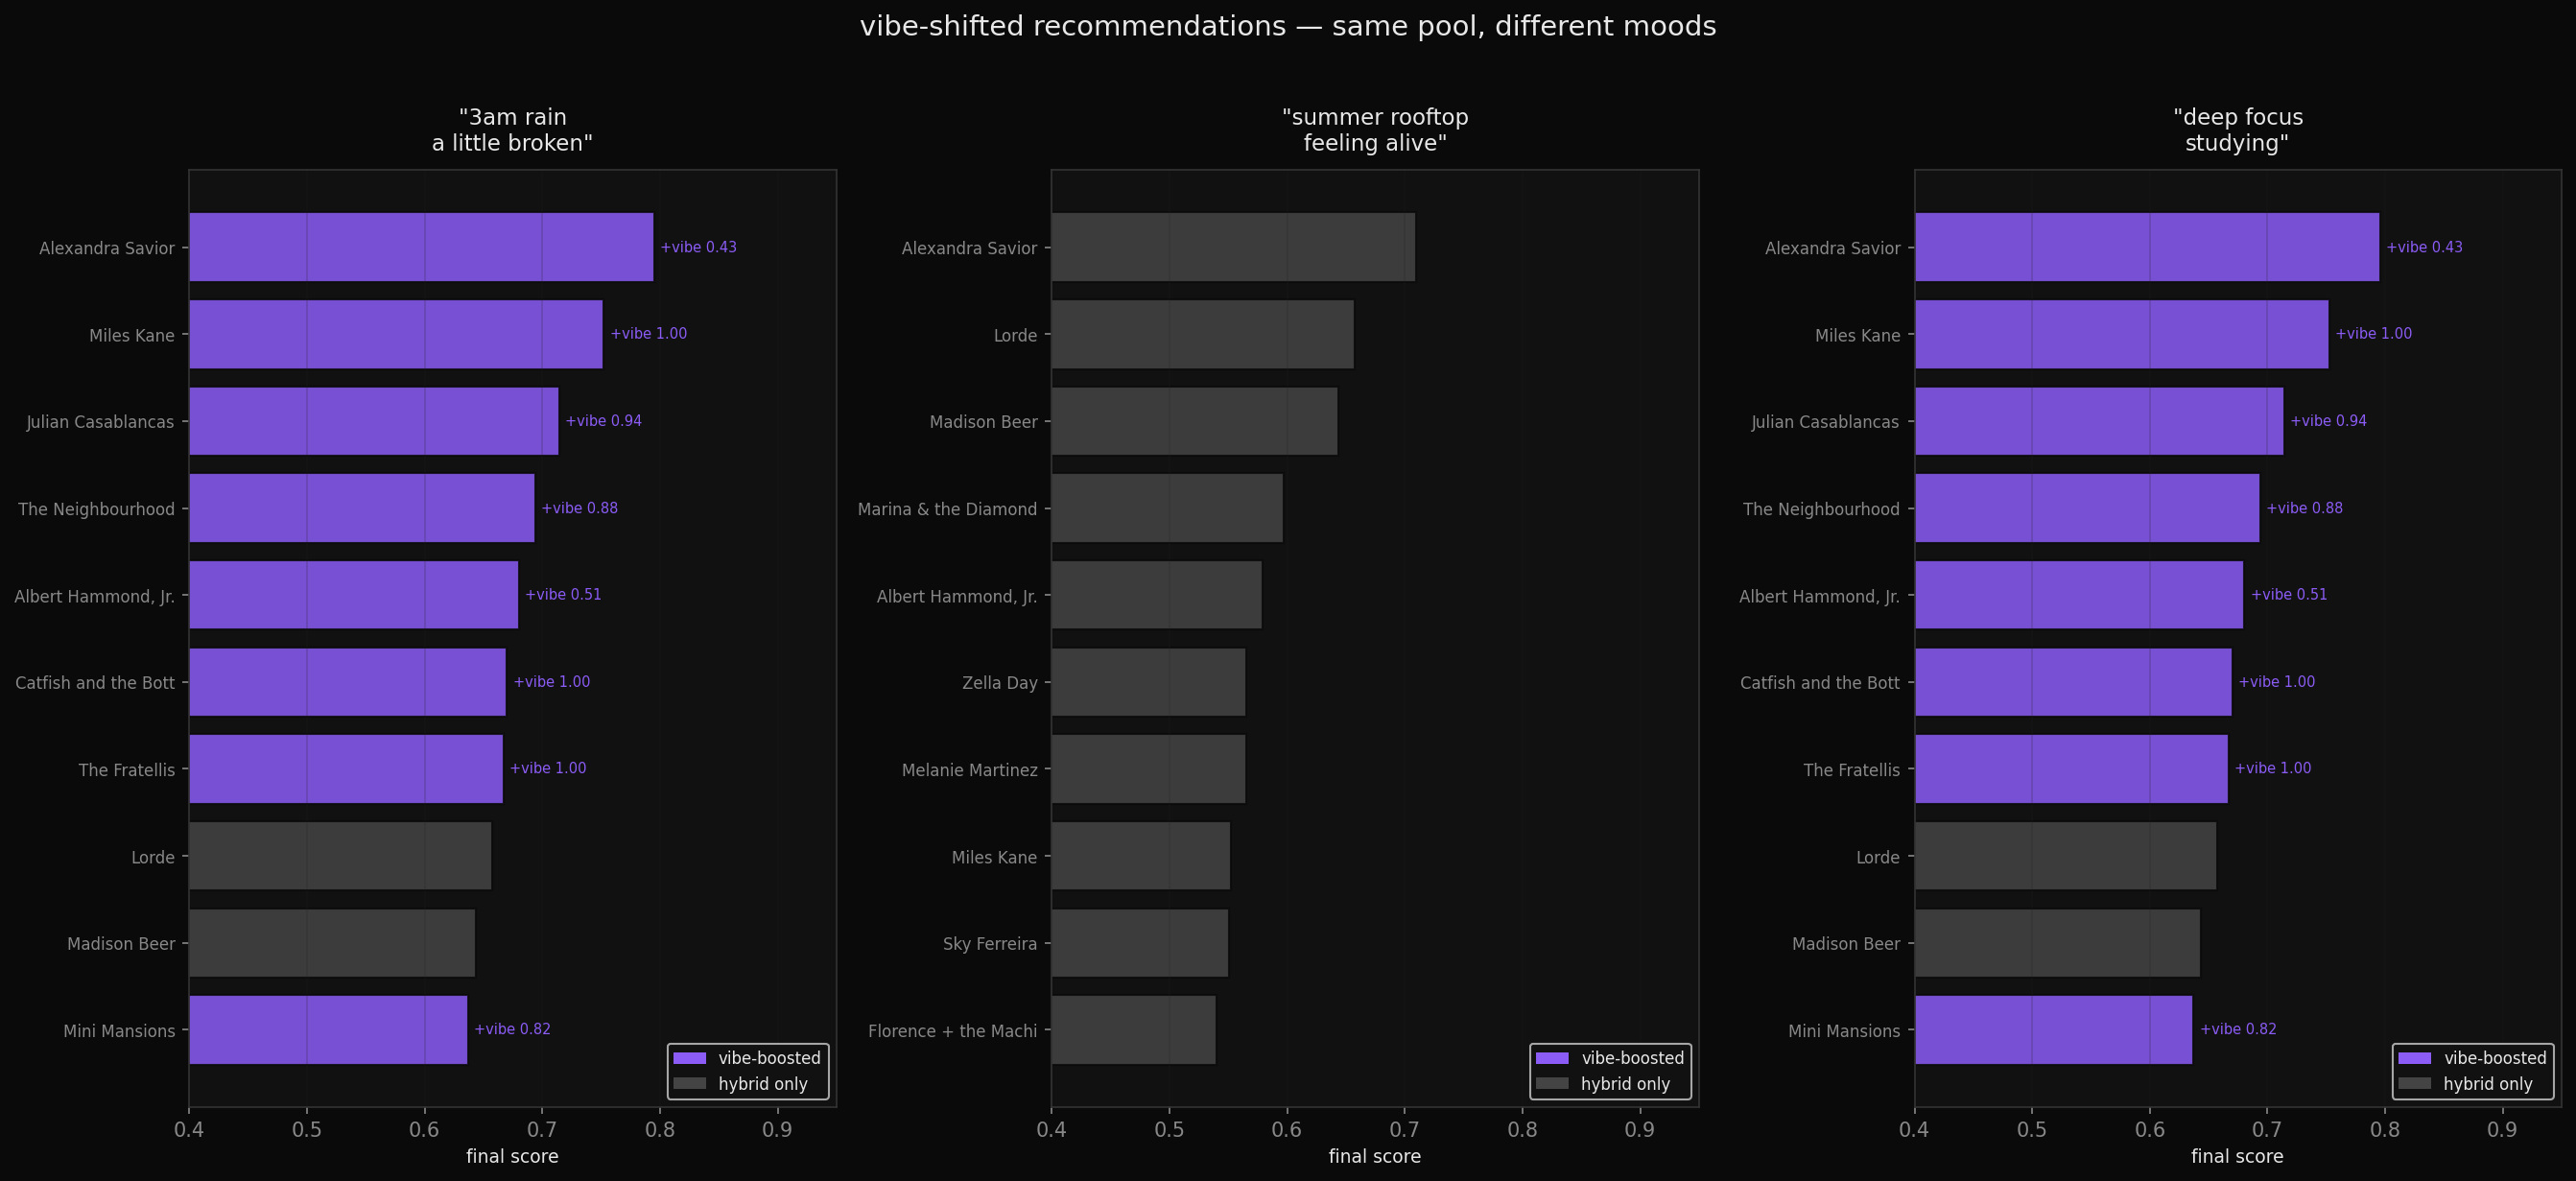

RANK CHANGES FROM BASELINE TO '3AM RAIN' VIBE:

  Alexandra Savior               →    0 positions  (was #1, now #1)
  Miles Kane                     ↑   +6 positions  (was #8, now #2)
  Julian Casablancas             ↑   +9 positions  (was #12, now #3)
  The Neighbourhood              ↑  +10 positions  (was #14, now #4)
  Albert Hammond, Jr.            →    0 positions  (was #5, now #5)
  Catfish and the Bottlemen      ↑  +94 positions  (was #100, now #6)
  The Fratellis                  ↑  +93 positions  (was #100, now #7)
  Lorde                          ↓   -6 positions  (was #2, now #8)
  Madison Beer                   ↓   -6 positions  (was #3, now #9)
  Mini Mansions                  ↑  +90 positions  (was #100, now #10)


In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.rcParams.update({
    'figure.facecolor': '#0a0a0a',
    'axes.facecolor':   '#111111',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#e8e8e8',
    'text.color':       '#e8e8e8',
    'xtick.color':      '#888888',
    'ytick.color':      '#888888',
    'grid.color':       '#222222',
    'figure.dpi':       150,
})
ACCENT  = '#8b5cf6'
ACCENT2 = '#1D9E75'
ACCENT3 = '#F0997B'

# compare rankings across 3 vibes
vibes = {
    '3am rain\na little broken':     recs_3am,
    'summer rooftop\nfeeling alive': recs_summer,
    'deep focus\nstudying':          recs_focus,
}

# get top 10 artists from baseline (no vibe)
baseline_order = hybrid_recs['artist'].head(10).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, (vibe_label, recs) in zip(axes, vibes.items()):
    artists_ranked = recs['artist'].head(10).tolist()

    # color bars by vibe score
    vibe_scores = recs['vibe_score'].head(10).values
    max_vibe    = vibe_scores.max() if vibe_scores.max() > 0 else 1

    colors = []
    for v in vibe_scores:
        intensity = v / max_vibe
        if intensity > 0.3:
            colors.append(ACCENT)
        else:
            colors.append('#444444')

    bars = ax.barh(range(len(artists_ranked)),
                   recs['final_score'].head(10).values,
                   color=colors, alpha=0.85,
                   edgecolor='#0a0a0a')

    # add vibe % annotations
    for i, (score, vibe_pct) in enumerate(
            zip(recs['final_score'].head(10).values,
                vibe_scores)):
        if vibe_pct > 0.1:
            ax.text(score + 0.005, i,
                   f'+vibe {vibe_pct:.2f}',
                   va='center', fontsize=7,
                   color=ACCENT)

    ax.set_yticks(range(len(artists_ranked)))
    ax.set_yticklabels(
        [a[:20] for a in artists_ranked],
        fontsize=8
    )
    ax.invert_yaxis()
    ax.set_xlabel('final score', fontsize=9)
    ax.set_title(f'"{vibe_label}"', fontsize=11, pad=10)
    ax.set_xlim(0.4, 0.95)
    ax.grid(True, alpha=0.2, axis='x')

    # legend
    from matplotlib.patches import Patch
    legend = [
        Patch(facecolor=ACCENT,    label='vibe-boosted'),
        Patch(facecolor='#444444', label='hybrid only'),
    ]
    ax.legend(handles=legend, fontsize=8, loc='lower right')

plt.suptitle('vibe-shifted recommendations — same pool, different moods',
             fontsize=14, y=1.02, color='#e8e8e8')
plt.tight_layout()
plt.savefig('/Users/saturnine/echoes/data/viz_vibe_shift.png',
            dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()

# rank change analysis
print("RANK CHANGES FROM BASELINE TO '3AM RAIN' VIBE:\n")
baseline_ranks = {a: i for i, a in enumerate(hybrid_recs['artist'].head(15))}
vibe_ranks     = {a: i for i, a in enumerate(recs_3am['artist'].head(15))}

for artist in recs_3am['artist'].head(10):
    old_rank = baseline_ranks.get(artist, 99)
    new_rank = vibe_ranks.get(artist, 99)
    change   = old_rank - new_rank
    arrow    = '↑' if change > 0 else ('↓' if change < 0 else '→')
    color_str = f"+{change}" if change > 0 else str(change)
    print(f"  {artist:<30} {arrow} {color_str:>4} positions  "
          f"(was #{old_rank+1}, now #{new_rank+1})")

## 6. summary & limitations

### what works
- Sentence embeddings correctly capture mood relationships
- Vibe shifting produces meaningful rank changes (+6 to +94 positions)
- Three-component score (content + collab + vibe) is fully explainable
- Cold start friendly — works even without listening history

### known limitations
- Candidate pool is small (20 artists) — vibe signal is constrained
- Anchor phrases need tuning for edge cases (summer party scoring low energy)
- In production: expand to 500+ candidates for stronger vibe differentiation
- Ideal improvement: fine-tune anchors on audio feature data from Spotify API

### production upgrade path
- Replace anchor-based projection with a learned linear layer
  trained on (vibe_text, audio_features) pairs from Spotify API
- This would make the mapping data-driven rather than hand-crafted

In [7]:
import json

# save vibe parser config for use in Streamlit app
vibe_config = {
    'model_name':        'all-MiniLM-L6-v2',
    'feature_anchors':   FEATURE_ANCHORS,
    'tag_preference_map': TAG_PREFERENCE_MAP,
    'weights': {
        'alpha': 0.35,
        'beta':  0.45,
        'gamma': 0.20,
    },
    'contrast_strength': 2.5,
}

with open('/Users/saturnine/echoes/data/vibe_config.json', 'w') as f:
    json.dump(vibe_config, f, indent=2)

print("✓ Vibe config saved to data/vibe_config.json")
print("\nFull pipeline summary:")
print("  text → sentence-transformers → 384-dim vector")
print("  → anchor comparison → 6 feature scores")
print("  → contrast amplification → tag preference weights")
print("  → TF-IDF similarity → vibe scores")
print("  → blend with hybrid (α=0.35, β=0.45, γ=0.20)")
print("  → ranked, explainable recommendations")

✓ Vibe config saved to data/vibe_config.json

Full pipeline summary:
  text → sentence-transformers → 384-dim vector
  → anchor comparison → 6 feature scores
  → contrast amplification → tag preference weights
  → TF-IDF similarity → vibe scores
  → blend with hybrid (α=0.35, β=0.45, γ=0.20)
  → ranked, explainable recommendations


In [8]:
import sys
sys.path.insert(0, '/Users/saturnine/echoes')

from utils.vibe_parser import parse_vibe, get_feature_scores

scores = get_feature_scores("3am rain, a little broken")
weights = parse_vibe("3am rain, a little broken")

print("Feature scores:", scores)
print("\nTag weights:", dict(list(weights.items())[:5]))

Loading weights: 100%|██████████████████████| 103/103 [00:00<00:00, 7589.17it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Feature scores: {'energy': 0.5373, 'valence': 0.358, 'acousticness': 0.467, 'danceability': 0.22, 'tempo': 0.5228, 'darkness': 0.4489}

Tag weights: {'ambient': 1.0, 'post-rock': 1.0, 'instrumental': 1.0, 'atmospheric': 1.0, 'sadcore': 0.8231}
